# Induced-EQ Background Comparison

This notebook is an orchestration layer: experiment choices stay here, while model-spec validation, checkpoint/catalog loading, background extraction, plotting, forecast sampling, catalog tests, and cache selection live in `src.utils.induced_bg_comparison`.

The default workflow compares full-history and single-window background intensities, samples forecasts, runs N/M tests, and optionally evaluates sliding windows or a latent GP background. Export names always include `MODEL_SPEC_CONFIG_NAME`.

## 1. Environment and imports

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src'.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.forecast_eval import apply_publication_style, evaluate_sliding_window_forecast_plots
from src.utils.induced_bg_comparison import (
    BackgroundComparisonLayout,
    BackgroundComparisonStyle,
    build_model_style_map,
    catalog_summary,
    comparison_output_stem,
    configure_publication_style,
    load_comparison_context,
    load_model_spec_selection,
    model_registry_summary,
    plot_background_comparison,
    plot_latent_background,
    plot_multi_model_forecasts,
    plot_primary_catalog_tests,
    prepare_full_background_data,
    prepare_window_background_data,
    resolve_sliding_cache_selection,
    sample_registry_forecasts,
    save_figure_bundle,
)
from src.utils.utils import set_seed

apply_publication_style()
SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

NOTEBOOK_NAME = 'induced_eq_bg_comparison'
MODEL_SPEC_CONFIG_PATH = (
    PROJECT_ROOT / 'notebooks/config/model_specs' / NOTEBOOK_NAME
    / f'model_specs.{NOTEBOOK_NAME}.v1.json'
)
OUTPUT_DIR = PROJECT_ROOT / 'notebooks/figs/bg_cmp'
LEGACY_SLIDING_CACHE_DIR = PROJECT_ROOT / 'notebooks/figs/bg_cmp_sliding'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def report_saved(paths):
    for path in paths.values():
        print(f'Saved: {path}')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0
OUTPUT_DIR: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp


## 2. Experiment configuration

Most runs only need `MODEL_SPEC_CONFIG_NAME`, the single-window settings, and the execution switches.

In [2]:
DEFAULT_MODEL_SPEC_CONFIG_NAME = 'hd_cmp_st1'
MODEL_SPEC_CONFIG_NAME = os.environ.get(
    'MODEL_SPEC_CONFIG_NAME', DEFAULT_MODEL_SPEC_CONFIG_NAME
)
PRIMARY_MODEL_NAME_OVERRIDE = os.environ.get('PRIMARY_MODEL_NAME') or None

LAYOUT = BackgroundComparisonLayout(
    overlay_background=True,
    panel_b_only=False,
    suppress_titles=True,
)
STYLE = BackgroundComparisonStyle(dpi=600)
MODEL_STYLE_OVERRIDES = {}

T_FORECAST = 50 
FORECAST_DURATION = 10
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = min(NUM_SAMPLES, 1000)
SAMPLE_SEED = 3
USE_SHARED_SAMPLE_SEED = True
SEQUENCE_IDX = 0
USE_TORCH_COMPILE = False
MODEL_MM = 6.5

FORECAST_B_SAMPLING = 'model'
UPDATER_NAME = 'bayesian_gr'
UPDATER_CFG = {'delta': 0.98, 'a0': 50, 'init_b_target': 1}

DRAW_FULL_BACKGROUND = True
DRAW_WINDOW_BACKGROUND = True
RUN_FORECAST_SAMPLING = True
DRAW_FORECAST_TRAJECTORIES = True
RUN_CATALOG_TESTS = True
DRAW_LATENT_BACKGROUND = True

RUN_SLIDING_WINDOW_FORECAST = False
SLIDING_DURATION = 1
SLIDING_STEP = 1
SLIDING_QUANTILES = (2.5, 97.5)
SLIDING_VIEW_MODE = 'zoomed'  # Options: 'zoomed', 'full', 'auto'
SLIDING_LOAD_CACHE = True
SLIDING_FORCE_RECOMPUTE = False
SLIDING_USE_CHECKPOINT_CACHE = True
SLIDING_FALLBACK_TO_NOTEBOOK_CACHE = True
SLIDING_CACHE_PREFIX = 'sliding_window_cache_model_model'
SLIDING_CACHE_FILENAME = None

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)
print(
    f'Config={MODEL_SPEC_CONFIG_NAME} | window=[{window_start:g}, {window_end:g}] '
    f'| samples={NUM_SAMPLES}'
)

Config=hd_cmp_st1 | window=[50, 60] | samples=1000


## 3. Load validated model specs, checkpoints, and catalog

In [3]:
selection = load_model_spec_selection(
    MODEL_SPEC_CONFIG_PATH,
    MODEL_SPEC_CONFIG_NAME,
    primary_override=PRIMARY_MODEL_NAME_OVERRIDE,
)
configure_publication_style(STYLE)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
model_style_map = build_model_style_map(
    selection.specs, STYLE, MODEL_STYLE_OVERRIDES
)
context = load_comparison_context(
    selection,
    project_root=PROJECT_ROOT,
    data_root=PROJECT_ROOT / 'data',
    device=DEVICE,
    compile_models=USE_TORCH_COMPILE,
    model_magnitude_max=MODEL_MM,
)
if not 0 <= SEQUENCE_IDX < len(context.sequences):
    raise IndexError(
        f'SEQUENCE_IDX={SEQUENCE_IDX} outside [0, {len(context.sequences) - 1}]'
    )
seq = context.sequences[SEQUENCE_IDX]

print(f'Available configs: {", ".join(selection.available_configs)}')
display(catalog_summary(context, SEQUENCE_IDX))
display(model_registry_summary(context))

Available configs: CB_HAB1a, CB_HAB4, CCL, PNR_1z, St1_2018, bg_cmp_pnr, bg_cmp_st1, hd_cmp_cb1a, hd_cmp_cb1a_conv, hd_cmp_pnr, hd_cmp_st1


/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


,spec_config,primary_model,catalog_registry,dataset,sequence_index,events,magnitude_completeness,start_ts
0,hd_cmp_st1,mamba(ETAS),St1-2018-Standard,St1-2018,0,30252,-0.5,2018-06-04 05:27:26.351


,model,primary,dataset,background_scale,effective_branching_ratio,checkpoint
0,mamba(ETAS),True,St1-2018,1040.632568,0.686625,/root/autodl-tmp/em_eqf/experiments/etas_multi...
1,mamba(RECAST),False,St1-2018,1017.472046,NaN,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...


## 4. Full-history background comparison

Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/background_hd_cmp_st1.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/background_hd_cmp_st1.png


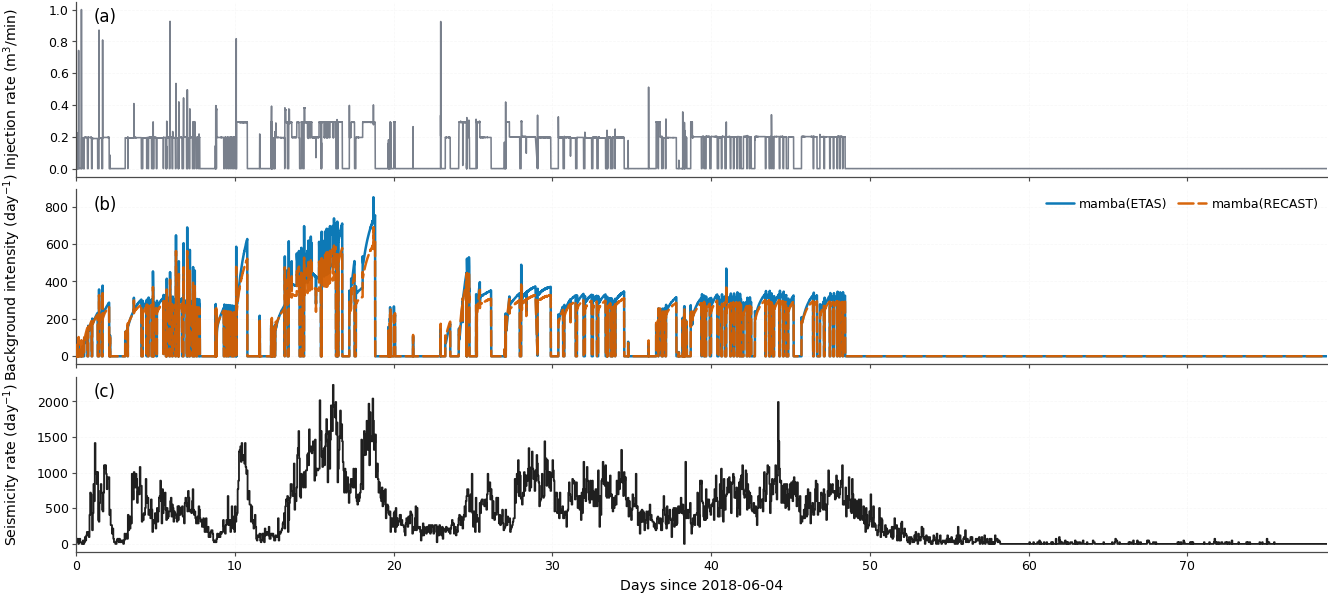

In [4]:
if DRAW_FULL_BACKGROUND:
    full_background_data = prepare_full_background_data(
        context,
        sequence_index=SEQUENCE_IDX,
        device=DEVICE,
        model_style_map=model_style_map,
        style=STYLE,
    )
    full_background_fig, _ = plot_background_comparison(
        full_background_data,
        layout=LAYOUT,
        style=STYLE,
        figure_width=STYLE.full_width + 4,
    )
    stem = comparison_output_stem(
        'background', selection.config_name, layout=LAYOUT
    )
    report_saved(
        save_figure_bundle(
            full_background_fig,
            OUTPUT_DIR,
            stem,
            style=STYLE,
            suppress_titles=LAYOUT.suppress_titles,
        )
    )
    plt.show()
else:
    print('DRAW_FULL_BACKGROUND=False; skipped full-history figure.')

## 5. Single-window background comparison

This cell also prepares `past_sequence` and `observed_sequence` for forecast sampling and tests.

Observed events in window: 826


/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


,model,background_forecast_count
0,mamba(ETAS),0.0
1,mamba(RECAST),0.0


Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/window_hd_cmp_st1.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/window_hd_cmp_st1.png


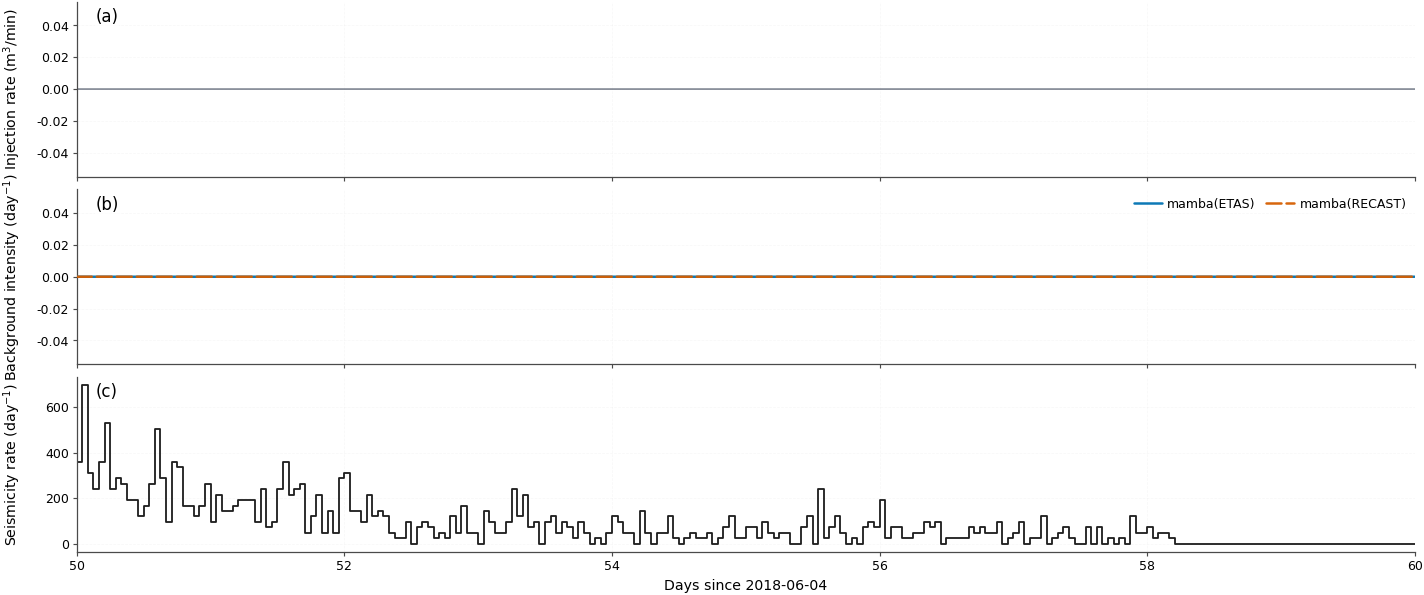

In [5]:
window_data = prepare_window_background_data(
    context,
    seq,
    window_start=window_start,
    window_end=window_end,
    model_style_map=model_style_map,
    style=STYLE,
)
past_sequence = window_data['past_sequence']
observed_sequence = window_data['observed_sequence']
print(f'Observed events in window: {len(observed_sequence)}')
display(window_data['background_counts'])

if DRAW_WINDOW_BACKGROUND:
    window_fig, _ = plot_background_comparison(
        window_data, layout=LAYOUT, style=STYLE, figure_width=STYLE.wide_width
    )
    stem = comparison_output_stem(
        'window', selection.config_name, layout=LAYOUT
    )
    report_saved(
        save_figure_bundle(
            window_fig,
            OUTPUT_DIR,
            stem,
            style=STYLE,
            suppress_titles=LAYOUT.suppress_titles,
        )
    )
    plt.show()
else:
    print('DRAW_WINDOW_BACKGROUND=False; skipped single-window figure.')

## 6. Multi-model forecast sampling and trajectories

  0%|          | 0/1000 [00:00<?, ?it/s]

,model,b_sampling,seed,forecasts,mean_count,median_count,zero_inter_time_forecasts
0,mamba(ETAS),model,3,1000,231.598,223.0,0
1,mamba(RECAST),model,3,1000,198.729,187.0,0


Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/forecasts_hd_cmp_st1.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/forecasts_hd_cmp_st1.png


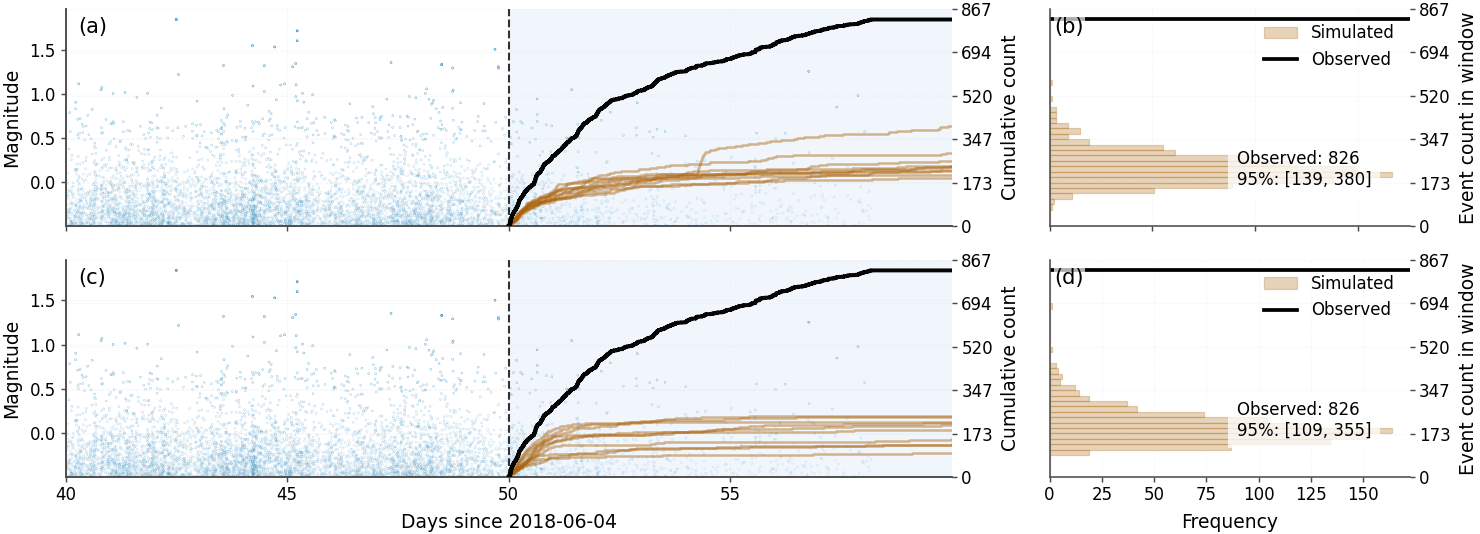

In [6]:
forecasts_by_model = None
sampling_summary_df = None
if RUN_FORECAST_SAMPLING:
    forecasts_by_model, sampling_summary_df = sample_registry_forecasts(
        context,
        past_sequence=past_sequence,
        background_cache_sequence=seq,
        duration=FORECAST_DURATION,
        num_samples=NUM_SAMPLES,
        samples_per_batch=SAMPLES_PER_BATCH,
        seed=SAMPLE_SEED,
        shared_seed=USE_SHARED_SAMPLE_SEED,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_name=UPDATER_NAME,
        updater_config=UPDATER_CFG,
        device=DEVICE,
    )
    display(sampling_summary_df)

    if DRAW_FORECAST_TRAJECTORIES:
        forecast_fig, _ = plot_multi_model_forecasts(
            seq,
            forecasts_by_model,
            xlabel=window_data['xlabel'],
            style=STYLE,
        )
        stem = comparison_output_stem('forecasts', selection.config_name)
        report_saved(
            save_figure_bundle(
                forecast_fig, OUTPUT_DIR, stem, style=STYLE, suppress_titles=True
            )
        )
        plt.show()
else:
    print('RUN_FORECAST_SAMPLING=False; forecast-dependent cells will be skipped.')

## 7. N-test and M-test for the primary model

,observed_count,forecast_count_mean,empty_forecasts,non_empty_forecasts,forecast_magnitude_min,forecast_magnitude_max,observed_magnitude_min,observed_magnitude_max
0,826,231.598,0,1000,-0.499996,2.603083,-0.495703,1.253443


Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/n_test_hd_cmp_st1_mamba_ETAS.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/n_test_hd_cmp_st1_mamba_ETAS.png
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/m_test_hd_cmp_st1_mamba_ETAS.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp/m_test_hd_cmp_st1_mamba_ETAS.png


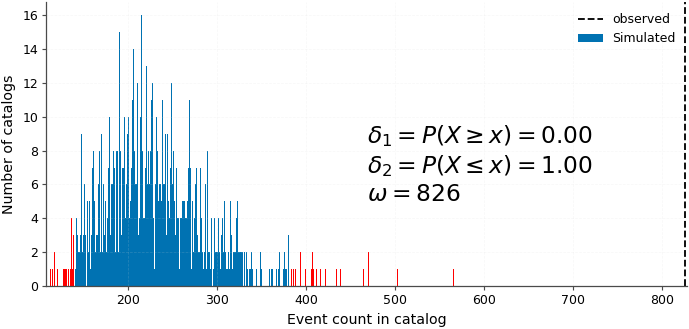

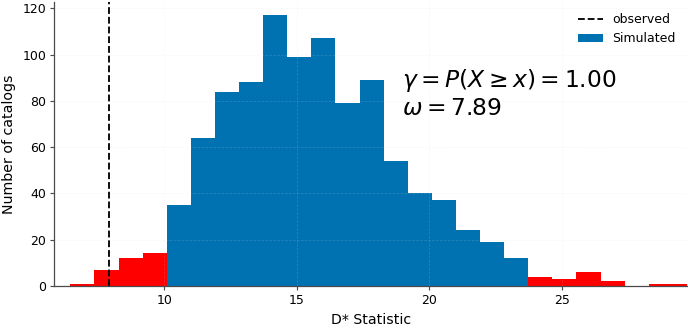

In [7]:
if RUN_CATALOG_TESTS and forecasts_by_model is not None:
    primary_forecasts = forecasts_by_model[selection.primary_model]
    test_summary, n_test_fig, m_test_fig = plot_primary_catalog_tests(
        primary_forecasts,
        observed_sequence,
        magnitude_completeness=context.magnitude_completeness,
        style=STYLE,
    )
    display(pd.DataFrame([test_summary]))

    n_stem = comparison_output_stem(
        'n_test',
        selection.config_name,
        primary_model=selection.primary_model,
    )
    m_stem = comparison_output_stem(
        'm_test',
        selection.config_name,
        primary_model=selection.primary_model,
    )
    report_saved(
        save_figure_bundle(
            n_test_fig, OUTPUT_DIR, n_stem, style=STYLE, suppress_titles=True
        )
    )
    report_saved(
        save_figure_bundle(
            m_test_fig, OUTPUT_DIR, m_stem, style=STYLE, suppress_titles=True
        )
    )
    plt.show()
elif RUN_CATALOG_TESTS:
    print('Catalog tests skipped because forecasts are unavailable.')
else:
    print('RUN_CATALOG_TESTS=False; skipped N/M tests.')

## 8. Optional sliding-window evaluation

Disabled by default. Cache discovery and compatibility checks are delegated to `src`.

In [8]:
if RUN_SLIDING_WINDOW_FORECAST:
    checkpoint_dir = context.checkpoint_path.parent
    cache_dirs = []
    if SLIDING_USE_CHECKPOINT_CACHE:
        cache_dirs.append(checkpoint_dir)
    if SLIDING_FALLBACK_TO_NOTEBOOK_CACHE:
        cache_dirs.append(LEGACY_SLIDING_CACHE_DIR)
    if not cache_dirs:
        cache_dirs.append(LEGACY_SLIDING_CACHE_DIR)

    cache_selection = resolve_sliding_cache_selection(
        seq,
        cache_directories=cache_dirs,
        explicit_filename=SLIDING_CACHE_FILENAME,
        duration=SLIDING_DURATION,
        slide_step=SLIDING_STEP,
        quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        script_predict_b=bool(getattr(context.args, 'predict_b', False)),
        script_sampling_seed=int(getattr(context.args, 'seed', 0)),
        prefix=SLIDING_CACHE_PREFIX,
    )
    sliding_plot_dir = OUTPUT_DIR / comparison_output_stem(
        'sliding', selection.config_name
    )
    sliding_plot_dir.mkdir(parents=True, exist_ok=True)
    print(
        f'Sliding cache: {cache_selection.path} '
        f'({cache_selection.contract_name})'
    )

    sliding_result = evaluate_sliding_window_forecast_plots(
        model=context.model,
        seq=seq,
        device=DEVICE,
        catalog_ds=context.catalog_ds,
        checkpoint_dir=cache_selection.path.parent,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        predict_b=cache_selection.predict_b,
        bg_cache_seq=seq,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=SLIDING_LOAD_CACHE,
        force_recompute_sliding=SLIDING_FORCE_RECOMPUTE,
        sliding_cache_filename=cache_selection.path.name,
        sampling_seed=cache_selection.sampling_seed,
        save_plots=True,
        plot_output_dir=sliding_plot_dir,
    )
    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        metrics = {
            key: sliding_result.get(key)
            for key in ('coverage', 'mae', 'rmse', 'crps', 'lp_nb', 'w95')
        }
        display(pd.DataFrame([metrics]))
else:
    print('RUN_SLIDING_WINDOW_FORECAST=False; skipped sliding evaluation.')

RUN_SLIDING_WINDOW_FORECAST=False; skipped sliding evaluation.


## 9. Optional latent-background posterior

In [9]:
if DRAW_LATENT_BACKGROUND:
    latent_fig = plot_latent_background(
        context.model,
        model_label=selection.primary_model,
        model_style=model_style_map[selection.primary_model],
        style=STYLE,
        device=DEVICE,
    )
    if latent_fig is None:
        print('Primary background has no compatible latent GP interface; skipped.')
    else:
        stem = comparison_output_stem(
            'latent',
            selection.config_name,
            primary_model=selection.primary_model,
        )
        report_saved(
            save_figure_bundle(
                latent_fig, OUTPUT_DIR, stem, style=STYLE, suppress_titles=False
            )
        )
        plt.show()
else:
    print('DRAW_LATENT_BACKGROUND=False; skipped latent posterior.')

Primary background has no compatible latent GP interface; skipped.
